In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
import random
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
dataset_path = 'numpy_data/numpy_bitmap'
CLASS_LEN = 1000
BATCH_SIZE = 32
SEED = 66
EPOCHS = 10
FILES_LEN = 30

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [22]:
files = os.listdir(dataset_path)[:FILES_LEN]
classes = len(files)
print(classes, files)
class_names = []

all_images = []
all_labels = []
for idx, file in enumerate(files):
    class_name = file.replace(' ', '_').replace('.npy', '')
    class_names.append(class_name)
    data = np.load(os.path.join(dataset_path, file)).astype(np.float32)
    data = data[:CLASS_LEN]
    data = data / 255.0
    data = data.reshape(-1, 28, 28)
    all_images.extend(data)
    all_labels.extend([idx] * len(data))

print(f"Total images: {len(all_images)}, Total labels: {classes}")

30 ['aircraft carrier.npy', 'airplane.npy', 'alarm clock.npy', 'ambulance.npy', 'angel.npy', 'animal migration.npy', 'ant.npy', 'anvil.npy', 'apple.npy', 'arm.npy', 'asparagus.npy', 'axe.npy', 'backpack.npy', 'banana.npy', 'bandage.npy', 'barn.npy', 'baseball bat.npy', 'baseball.npy', 'basket.npy', 'basketball.npy', 'bat.npy', 'bathtub.npy', 'beach.npy', 'bear.npy', 'beard.npy', 'bed.npy', 'bee.npy', 'belt.npy', 'bench.npy', 'bicycle.npy']
Total images: 30000, Total labels: 30


In [23]:
print(f"Class names: {class_names}")

Class names: ['aircraft_carrier', 'airplane', 'alarm_clock', 'ambulance', 'angel', 'animal_migration', 'ant', 'anvil', 'apple', 'arm', 'asparagus', 'axe', 'backpack', 'banana', 'bandage', 'barn', 'baseball_bat', 'baseball', 'basket', 'basketball', 'bat', 'bathtub', 'beach', 'bear', 'beard', 'bed', 'bee', 'belt', 'bench', 'bicycle']


In [ ]:
def plot_samples_with_labels(data, labels, class_names, n=5):
    plt.figure(figsize=(n+2, n+2))
    for i in range(n * n):
        idx = np.random.randint(0, len(data))

        plt.subplot(n, n, i + 1)
        plt.imshow(data[idx], cmap='gray_r')

        class_idx = labels[idx]
        class_name = class_names[class_idx]
        plt.title(class_name, fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_samples_with_labels(all_images, all_labels, class_names)

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    all_images,
    all_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=all_labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp
)

print(f"Final split sizes:")
print(f"Train: {len(X_train)} ({len(X_train)/len(all_images)*100:.1f}%)")
print(f"Val: {len(X_val)} ({len(X_val)/len(all_images)*100:.1f}%)")
print(f"Test: {len(X_test)} ({len(X_test)/len(all_images)*100:.1f}%)")

Final split sizes:
Train: 24000 (80.0%)
Val: 3000 (10.0%)
Test: 3000 (10.0%)


In [6]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    # transforms.RandomRotation(15, fill=0),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), fill=0),
    # transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),  # grayscale -> 3-channel
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def apply_transform(images, transform, seed=SEED):
    random.seed(seed)
    torch.manual_seed(seed)
    return torch.stack([transform(img) for img in tqdm(images)])

# def apply_transform(images, transform, chunk_size=500, seed=SEED):
#     random.seed(seed)
#     torch.manual_seed(seed)
    
#     all_chunks = []
#     total_images = len(images)
    
#     for i in tqdm(range(0, total_images, chunk_size)):
#         chunk = images[i:min(i+chunk_size, total_images)]
        
#         # Process chunk
#         chunk_tensors = [transform(img) for img in chunk]
#         chunk_tensor = torch.stack(chunk_tensors)
#         all_chunks.append(chunk_tensor)
        
#         # Clear chunk tensors to free memory
#         del chunk_tensors
#         if device.type == 'cuda':
#             torch.cuda.empty_cache()
    
#     # Concatenate all chunks
#     result = torch.cat(all_chunks, dim=0)
    
#     # Clean up
#     del all_chunks
#     import gc
#     gc.collect()
    
#     return result


print("Applying transforms to training set")
X_train_tensor = apply_transform(X_train, train_transform)
print("Applying transforms to validation set")
X_val_tensor = apply_transform(X_val, eval_transform)
print("Applying transforms to test set")
X_test_tensor = apply_transform(X_test, eval_transform)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(f"\nTensor shapes:")
print(f"  Train: {X_train_tensor.shape}")
print(f"  Val:   {X_val_tensor.shape}")
print(f"  Test:  {X_test_tensor.shape}")

Applying transforms to training set


  0%|          | 0/24000 [00:00<?, ?it/s]

100%|██████████| 24000/24000 [00:34<00:00, 687.97it/s] 


Applying transforms to validation set


100%|██████████| 3000/3000 [00:04<00:00, 624.09it/s]


Applying transforms to test set


100%|██████████| 3000/3000 [00:03<00:00, 869.39it/s]



Tensor shapes:
  Train: torch.Size([24000, 3, 224, 224])
  Val:   torch.Size([3000, 3, 224, 224])
  Test:  torch.Size([3000, 3, 224, 224])


In [16]:
g = torch.Generator()
g.manual_seed(SEED)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=(device.type=='cuda'), generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=(device.type=='cuda'), generator=g)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=(device.type=='cuda'), generator=g)

print(f"Batches: Train {len(train_loader)}, Val {len(val_loader)}, Test {len(test_loader)}")

Batches: Train 750, Val 94, Test 94


In [17]:
num_classes = classes

# Load pretrained model
model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
print("Loaded pretrained ConvNeXt Tiny (ImageNet weights)")

# Modify the classifier head
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, num_classes)
)
# model.classifier[2] = nn.Linear(in_features, num_classes)

# TODO: For experiment and better results
# # Initialize the new layer
# nn.init.xavier_uniform_(model.classifier[2].weight)
# nn.init.zeros_(model.classifier[2].bias)

model = model.to(device)

print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loaded pretrained ConvNeXt Tiny (ImageNet weights)
ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementw

In [18]:
criterion = nn.CrossEntropyLoss()

# TODO: For experiment and better results
# # Use different learning rates for pretrained backbone and new classifier
# pretrained_params = []
# classifier_params = []
# for name, param in model.named_parameters():
#     if 'classifier' in name:
#         classifier_params.append(param)
#     else:
#         pretrained_params.append(param)

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.05)

# Cosine annealing scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(loader, desc='Validating')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / len(loader), 100. * correct / total, all_preds, all_labels

In [24]:
best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Starting training...")
print("="*60)

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'categories': class_names
        }, 'best_model.pth')
        print(f"✓ New best model saved! (Val Acc: {val_acc:.2f}%)")

    print("="*100)

print(f"\nTraining complete! Best validation accuracy: {best_val_acc:.2f}%")

Starting training...

Epoch 1/10


Validating: 100%|██████████| 94/94 [00:13<00:00,  6.91it/s]



Train Loss: 0.7232 | Train Acc: 79.78%
Val Loss:   0.7256 | Val Acc:   79.77%
LR: 0.000905
✓ New best model saved! (Val Acc: 79.77%)

Epoch 2/10


Validating: 100%|██████████| 94/94 [00:14<00:00,  6.38it/s]



Train Loss: 0.5779 | Train Acc: 83.70%
Val Loss:   0.6596 | Val Acc:   82.67%
LR: 0.000794
✓ New best model saved! (Val Acc: 82.67%)

Epoch 3/10


...


Train Loss: 0.0276 | Train Acc: 99.26%
Val Loss:   0.7683 | Val Acc:   86.10%
LR: 0.000024
✓ New best model saved! (Val Acc: 86.10%)

Epoch 9/10


Validating: 100%|██████████| 94/94 [00:14<00:00,  6.37it/s]



Train Loss: 0.0151 | Train Acc: 99.63%
Val Loss:   0.7926 | Val Acc:   86.10%
LR: 0.000000

Epoch 10/10


Validating: 100%|██████████| 94/94 [00:14<00:00,  6.35it/s]


Train Loss: 0.0129 | Train Acc: 99.67%
Val Loss:   0.7926 | Val Acc:   86.10%
LR: 0.000024

Training complete! Best validation accuracy: 86.10%


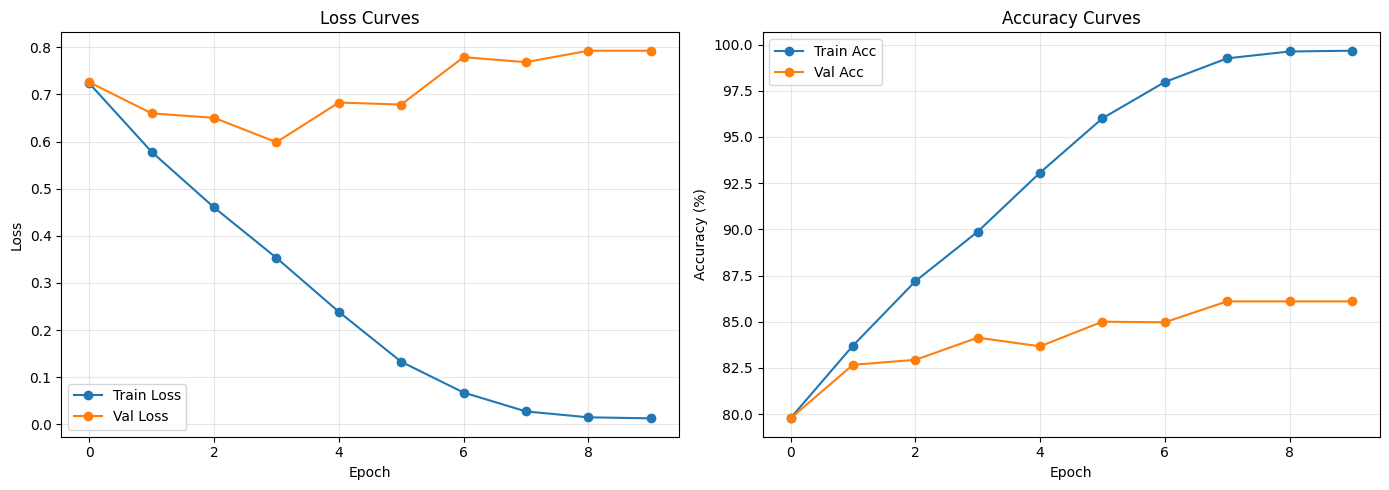

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train Acc', marker='o')
ax2.plot(history['val_acc'], label='Val Acc', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curves')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
categories = []
for idx, file in enumerate(files):
    class_name = file.replace(' ', '_').replace('.npy', '')
    categories.append(class_name)

models = ['model_epoc4', 'model_epoc6', 'model_epoc8']
for model_name in models:
    checkpoint = torch.load(f'{model_name}.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded {model_name} from epoch {checkpoint['epoch']+1} (Val Acc: {checkpoint['val_acc']:.2f}%)")

    test_loss, test_acc, test_preds, test_labels = validate_one_epoch(
        model, test_loader, criterion, device
    )

    print(f"Test Results:")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print("Classification Report:")
    print(classification_report(test_labels, test_preds, target_names=categories, digits=4))
    print("="*40)

Loaded model_epoc4 from epoch 4 (Val Acc: 84.13%)


Validating: 100%|██████████| 94/94 [00:12<00:00,  7.33it/s]


Test Results:
Test Loss: 0.6183
Test Accuracy: 83.90%
Classification Report:
                  precision    recall  f1-score   support

aircraft_carrier     0.6351    0.4700    0.5402       100
        airplane     0.8776    0.8600    0.8687       100
     alarm_clock     0.9213    0.8200    0.8677       100
       ambulance     0.9479    0.9100    0.9286       100
           angel     0.8936    0.8400    0.8660       100
animal_migration     0.6869    0.6800    0.6834       100
             ant     0.7000    0.9100    0.7913       100
           anvil     0.9175    0.8900    0.9036       100
           apple     0.9057    0.9600    0.9320       100
             arm     0.6786    0.9500    0.7917       100
       asparagus     0.8229    0.7900    0.8061       100
             axe     0.9362    0.8800    0.9072       100
        backpack     0.9355    0.8700    0.9016       100
          banana     0.9600    0.9600    0.9600       100
         bandage     0.9080    0.7900    0.8449     

Validating: 100%|██████████| 94/94 [00:12<00:00,  7.33it/s]


Test Results:
Test Loss: 0.6472
Test Accuracy: 85.37%
Classification Report:
                  precision    recall  f1-score   support

aircraft_carrier     0.6479    0.4600    0.5380       100
        airplane     0.8515    0.8600    0.8557       100
     alarm_clock     0.9348    0.8600    0.8958       100
       ambulance     0.9394    0.9300    0.9347       100
           angel     0.8947    0.8500    0.8718       100
animal_migration     0.6783    0.7800    0.7256       100
             ant     0.8958    0.8600    0.8776       100
           anvil     0.8762    0.9200    0.8976       100
           apple     0.9314    0.9500    0.9406       100
             arm     0.8505    0.9100    0.8792       100
       asparagus     0.9205    0.8100    0.8617       100
             axe     0.9479    0.9100    0.9286       100
        backpack     0.8598    0.9200    0.8889       100
          banana     0.9579    0.9100    0.9333       100
         bandage     0.8431    0.8600    0.8515     

Validating: 100%|██████████| 94/94 [00:12<00:00,  7.39it/s]

Test Results:
Test Loss: 0.7717
Test Accuracy: 85.40%
Classification Report:
                  precision    recall  f1-score   support

aircraft_carrier     0.6180    0.5500    0.5820       100
        airplane     0.8365    0.8700    0.8529       100
     alarm_clock     0.8763    0.8500    0.8629       100
       ambulance     0.9000    0.9000    0.9000       100
           angel     0.9255    0.8700    0.8969       100
animal_migration     0.7604    0.7300    0.7449       100
             ant     0.8725    0.8900    0.8812       100
           anvil     0.8738    0.9000    0.8867       100
           apple     0.9300    0.9300    0.9300       100
             arm     0.8462    0.8800    0.8627       100
       asparagus     0.8529    0.8700    0.8614       100
             axe     0.9670    0.8800    0.9215       100
        backpack     0.9072    0.8800    0.8934       100
          banana     0.9495    0.9400    0.9447       100
         bandage     0.8750    0.8400    0.8571     